# Lab 9

Description of lab:

Understand the assumptions and relative importance of the main 6 assumptions of regression analysis. Understand the inferential and predictive uncertainty. Evaluate validity through residual vs. fitted plots. Evaluate the appropriateness of a model through posterior predictive checks. Overfitting and use of AIC (Akaiki Information Criteria).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as spt

import statsmodels as sms
import statsmodels.formula.api as smf
import seaborn as sns

from cycler import cycler

plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams["axes.labelsize"]= 12
plt.rcParams["figure.facecolor"] = "#f2f2f2"
#plt.rcParams['figure.savefig.dpi'] = 100
plt.rcParams['savefig.edgecolor'] = "#f2f2f2"
plt.rcParams['savefig.facecolor'] ="#f2f2f2"
plt.rcParams["figure.figsize"] = [16,10]
plt.rcParams['savefig.bbox'] = "tight"
plt.rcParams['font.size'] = 14
greens = ['#66c2a4','#41ae76','#238b45','#006d2c','#00441b']
multi =['#66c2a4','#1f78b4','#a6cee3','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
plt.rcParams["axes.prop_cycle"] = cycler(color=multi)

In [2]:
pv = pd.read_csv("https://jmaurit.github.io/anv_statistikk/data/pv_csi_new.csv", index_col=0)

In [3]:
# Prepping the data:
pv['date'] = pd.to_datetime(pv['date'], format = '%Y-%m-%d')
pv = pv.sort_values(by = ['date'], ascending = True)
pv['time_days_m'] = pv['time_days'] - np.mean(pv['time_days'])
pv['time_days_m_sq'] = pv['time_days_m'] ** 2

In [7]:
mod1 = smf.ols('cost_per_kw ~ time_days_m + time_days_m_sq', data = pv).fit()
mod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            cost_per_kw   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.335
Method:                 Least Squares   F-statistic:                 2.688e+04
Date:                Mon, 04 Dec 2023   Prob (F-statistic):               0.00
Time:                        15:17:10   Log-Likelihood:            -9.4162e+05
No. Observations:              106551   AIC:                         1.883e+06
Df Residuals:                  106548   BIC:                         1.883e+06
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       6290.8428      6.985    900.577      0.000    6277.152    6304.534
time_days_m       -1.9218      0.009   -215.208      0.000      -1.939      -1.904
time_days_m_sq    -0.0003   1.14e-05    -24.333      0.000      -0.000      -0.000
==============================================================================
Omnibus:                   165044.969   Durbin-Watson:                   1.873
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        591611598.739
Skew:                           9.087   Prob(JB):                         0.00
Kurtosis:                     367.591   Cond. No.                     8.99e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.99e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [5]:
import datetime
T = (pv['date'].iloc[-1] - pv['date'].iloc[0]).days + 1

base = pv['date'].iloc[0]
date_list = [base + datetime.timedelta(days = x) for x in range(T)]
fake_dates = pd.to_datetime(pd.Series([date.strftime('%Y-%m-%d') for date in date_list]))

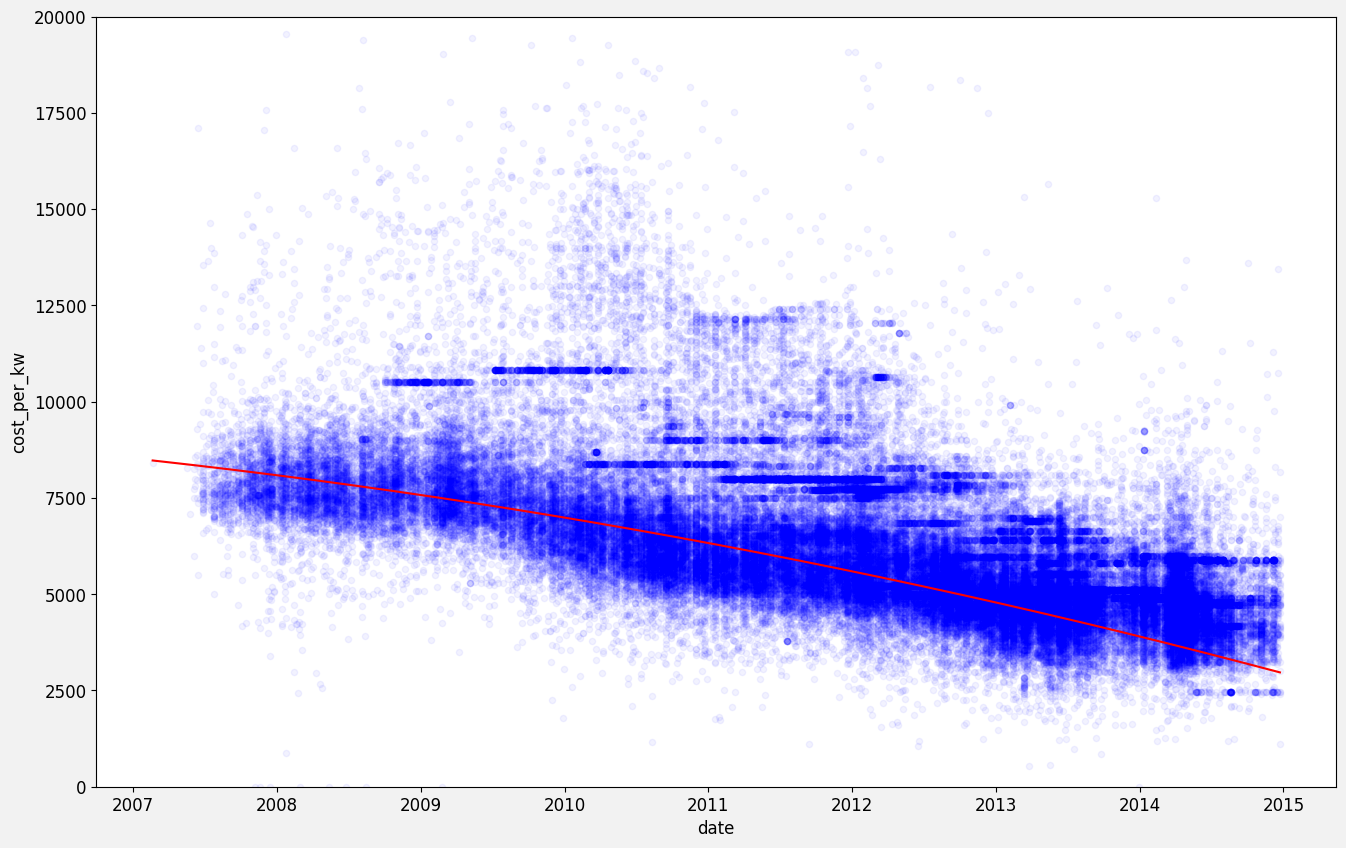

In [8]:
# Visualizing the model:
b0_hat = mod1.params.iloc[0]
b1_hat = mod1.params.iloc[1]
b2_hat = mod1.params.iloc[2]

x_line = np.linspace(0, T, T)
x_line_m = x_line - np.mean(x_line)
y_line = b0_hat + b1_hat * x_line_m + b2_hat * x_line_m ** 2

fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .05, color = 'blue', ax = ax)
ax.set_ylim(0, 20000)
ax.plot(fake_dates, y_line, color = 'red')
plt.show()

In [9]:
# Simulation to generate and draw the uncertainty:
df = mod1.df_resid
sigma_hat = np.sqrt(mod1.mse_resid)
bs_vcov = mod1.cov_params(scale = 1)
bs = mod1.params
bs_vcov

,Intercept,time_days_m,time_days_m_sq
Intercept,1.757302e-05,-7.169207e-09,-1.957946e-11
time_days_m,-7.169207e-09,2.871991e-11,1.714360e-14
time_days_m_sq,-1.957946e-11,1.714360e-14,4.682003e-17


##### A bit about the covariance-variance matrix and where coefficient standard errors come from (a bit technical)

In [16]:
# Coefficient standard errors that are reported in the regression output (scaled cov-var matrix):
vcov_scaled = sigma_hat ** 2 * bs_vcov
vcov_scaled

,Intercept,time_days_m,time_days_m_sq
Intercept,48.795076,-1.990676e-02,-5.436635e-05
time_days_m,-0.019907,7.974667e-05,4.760270e-08
time_days_m_sq,-0.000054,4.760270e-08,1.300053e-10


In [15]:
# Same as directly from the model:
mod1.cov_params()

,Intercept,time_days_m,time_days_m_sq
Intercept,48.795076,-1.990676e-02,-5.436635e-05
time_days_m,-0.019907,7.974667e-05,4.760270e-08
time_days_m_sq,-0.000054,4.760270e-08,1.300053e-10


In [17]:
# Extract the variance component from the diagonal corresponding to time_days_m:
vcov_scaled.iloc[1, 1]

7.974667228185018e-05

In [18]:
# Calculate the standard error for just the linear term of the time trend:
np.sqrt(vcov_scaled.iloc[1, 1])

0.008930099231355168

##### Simulating from a regression output

From lab 6 we know that: $\tfrac{s^2 \cdot (n - k)}{\sigma^2}$, where s is the the sample standard deviation, $\sigma$ is the 'true' standard deviation, and <br> $n - k$ are the degrees of freedom. From this we get that $\sigma \sim \hat{\sigma} \sqrt{\tfrac{n - k}{\chi^2(n - k)}}$

In [19]:
# With this we can simulate a random draw for sigma with:
sigma_sim = sigma_hat * np.sqrt(df / np.random.chisquare(df, 1))

In [35]:
# Create a scaled var-cov matrix with this sigma:
V_sim = np.array(bs_vcov) * sigma_sim ** 2

In [36]:
bs_sim = np.random.multivariate_normal(bs, V_sim, 1)
bs_sim

array([[ 6.28303903e+03, -1.91042632e+00, -2.49287462e-04]])

In [38]:
# Creating a function to do this several times:
def regSim(regMod):
    # Get the values from the model:
    nmk = regMod.df_resid # Degrees of freedom n - k.
    sigma_hat = np.sqrt(regMod.mse_resid) # Variance, standard deviation.
    bs_vcov = regMod.cov_params(scale = 1) # Variance-covariance matrix.
    bs = regMod.params # The coefficients of the model, the betas.

    # Create the simulated values:
    sigma_sim = sigma_hat * np.sqrt(nmk / np.random.chisquare(nmk, 1)) # Simulated standard deviation.
    V_sim = np.array(bs_vcov) * sigma_sim ** 2 # The scaled variance-covariance matrix.
    bs_sim = np.random.multivariate_normal(bs, V_sim, 1) # The simulated betas (coefficients).

    return bs_sim.flatten(), sigma_sim

In [39]:
# Run 50 simulations to see the inferential uncertainty:
nsim = 50
bs_sims = []
sigma_sims = []

for i in range(nsim):
    bs_sim, sigma_sim = regSim(mod1)
    bs_sims.append(bs_sim)
    sigma_sims.append(sigma_sim)

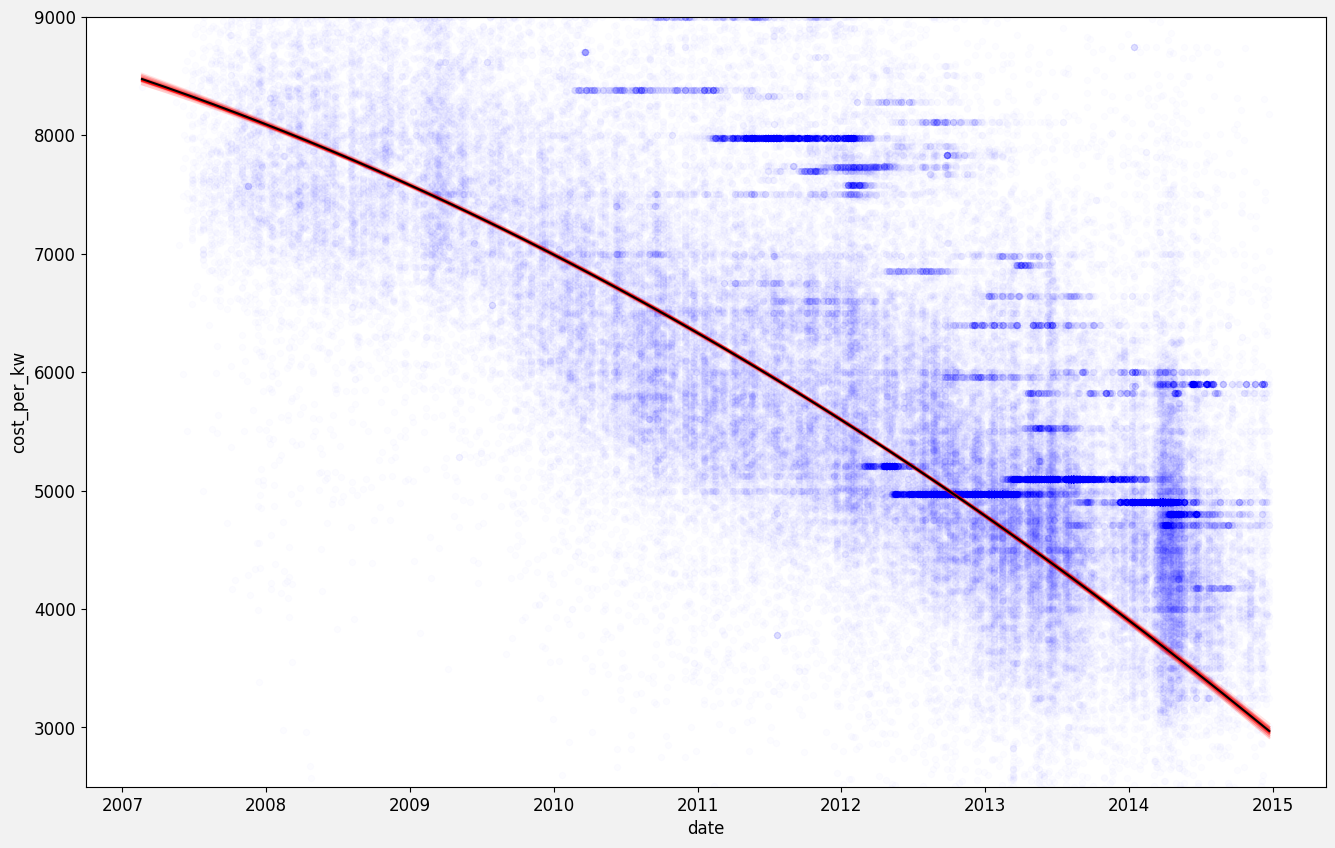

In [48]:
# Visualizing the inferential uncertainty:
fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .01, color = 'blue', ax = ax)
ax.plot(fake_dates, y_line, color = 'black', zorder = 10)

for i in range(nsim):
    y_line_sim = bs_sims[i][0] + bs_sims[i][1] * x_line_m + bs_sims[i][2] * x_line_m ** 2
    ax.plot(fake_dates, y_line_sim, alpha = .1, color = 'red')

ax.set_ylim(2500, 9000)
plt.show()

The uncertainty is very small, this is consistent with the very small standard errors and p-values we see in the regression output. This is the inferential uncertainty, which means the uncertainty about how well, in this case, the time trend line actually represents the 'true' time trend. 

##### Predictive uncertainty

What would the uncertainty of a prediction of the cost at any point in time be? This can be answered with the predictive uncertainty. To generate the predictive uncertainty all we need to do is to generate an extra error term based on the model estimated standard deviation, other than that its the same as the inferential uncertainty.

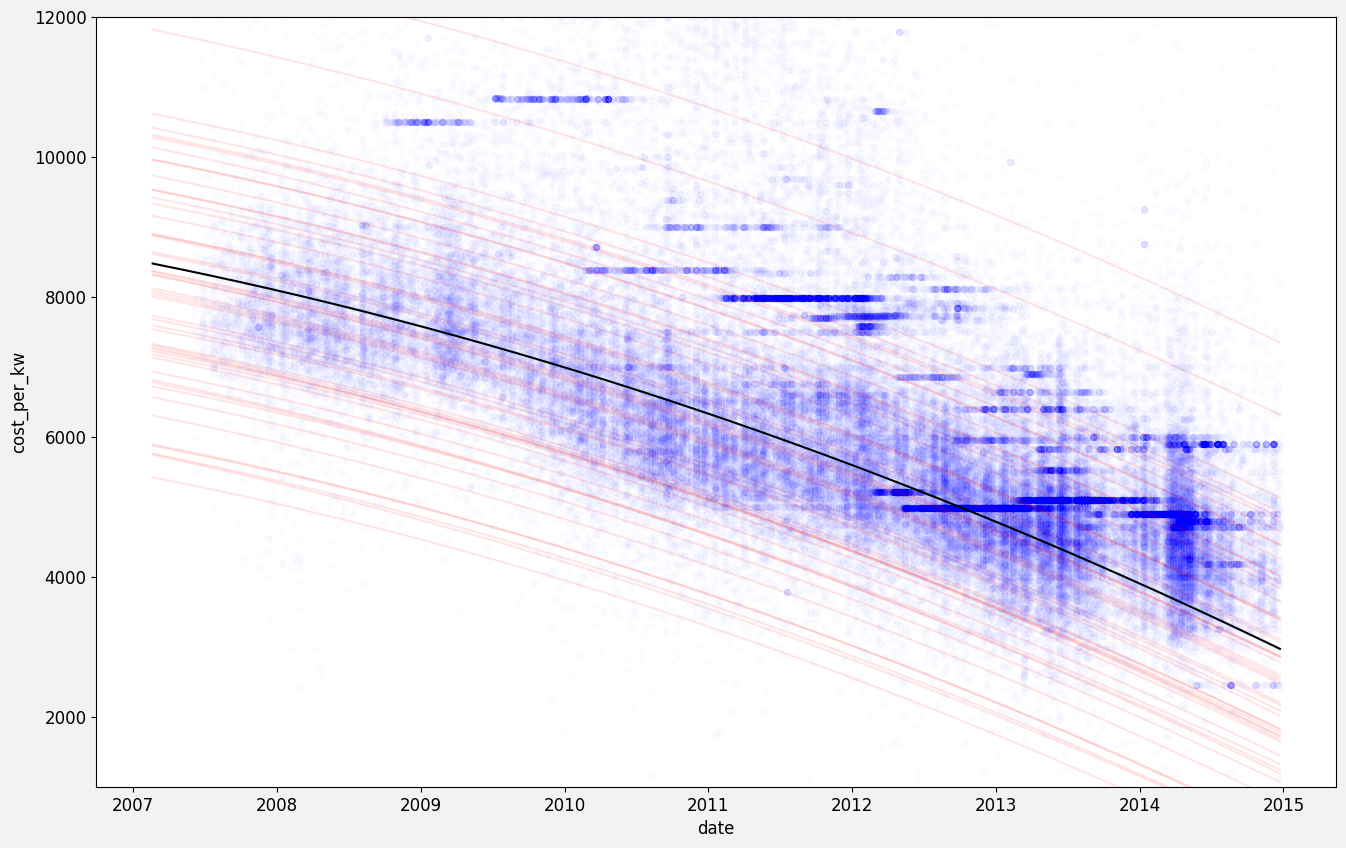

In [49]:
# Visualizing the predictive uncertainty:
fig, ax = plt.subplots()
pv.plot.scatter('date', 'cost_per_kw', alpha = .01, color = 'blue', ax = ax)
ax.plot(fake_dates, y_line, color = 'black', zorder = 10)

for i in range(nsim):
    y_line_sim = bs_sims[i][0] + bs_sims[i][1] * x_line_m + bs_sims[i][2] * x_line_m ** 2 + np.random.normal(0, sigma_hat)
    ax.plot(fake_dates, y_line_sim, alpha = .1, color = 'red')

ax.set_ylim(1000, 12000)
plt.show()

### Residual vs. fitted plot

An important tool in evaluating the validity and apropriateness of a regression model are plots of the residuals (the difference between the predicted values from the regression model, and the actual data). 

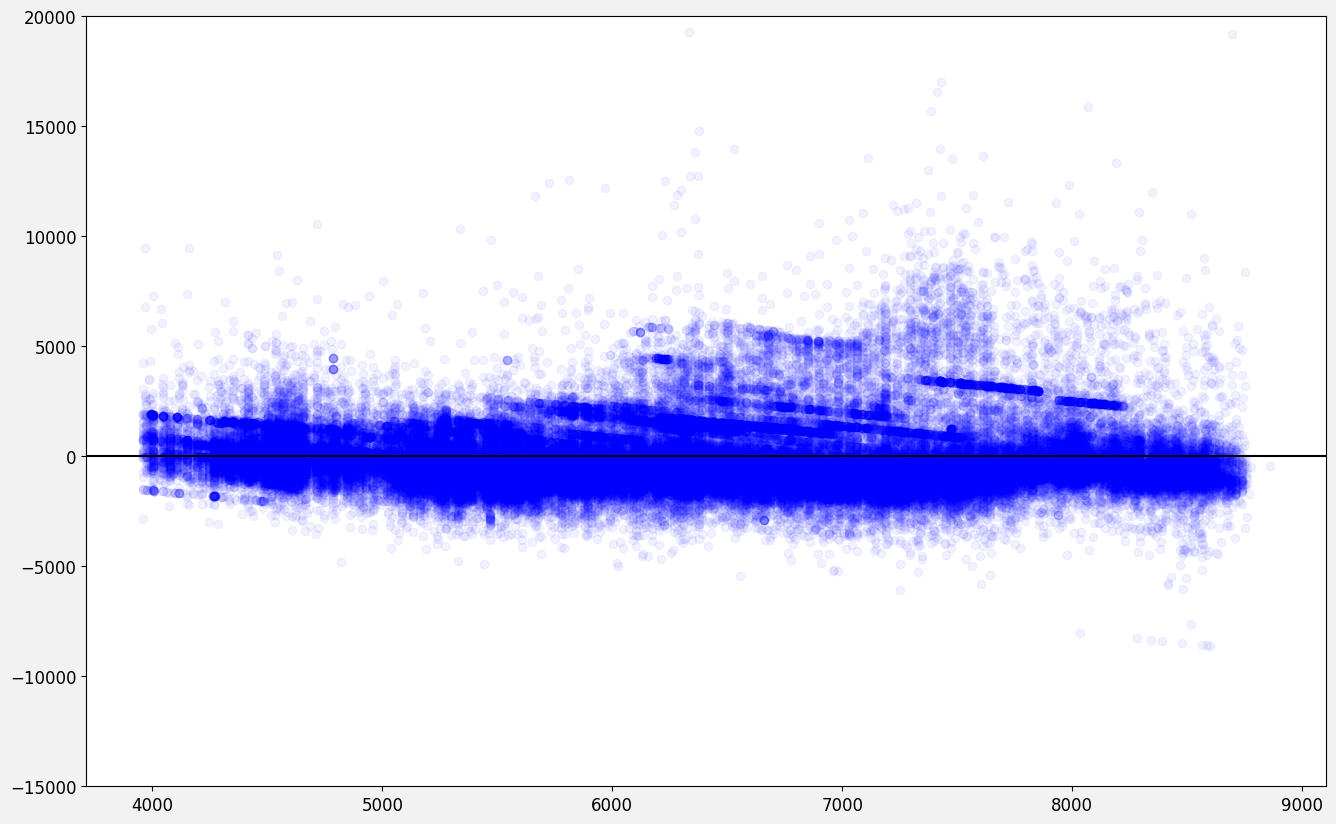

In [52]:
# Plotting the residuals from the model with quadratic trend:
fig, ax = plt.subplots()
ax.scatter(mod1.fittedvalues, mod1.resid, alpha = .05, color = 'blue')
ax.set_ylim(-15000, 20000)
ax.axhline(0, color = 'black')
plt.show()

We want to look for clear patterns in the figure. We want to see random dots centered around 0. In this case we can see some clear streaks in the data (we would like to understand this and ideally model explicitly), there also seems to be more variance towards the end of the period (more large positive residuals). 

##### Why residuals vs. predicted and not residuals vs actual

Why did I plot the residuals with the fitted values rather than the residuals with the actual values? I will perform a fake-data simulation to show why:

In [53]:
T = 3000
t = np.arange(0, T)
a = 9000
b1 = -1.9
b2 = -0.001
sigma = 1500

y_f = a + b1 * t + b2 * t ** 2 + np.random.normal(0, sigma, T)

fakeDF = pd.DataFrame({'y_f': y_f, 't': t, 'tsq': t ** 2})

In [54]:
y_f

array([ 8444.08700154, 11104.1590112 , 10011.92388994, ...,
       -4524.37156077, -7030.37830709, -7418.69106513])

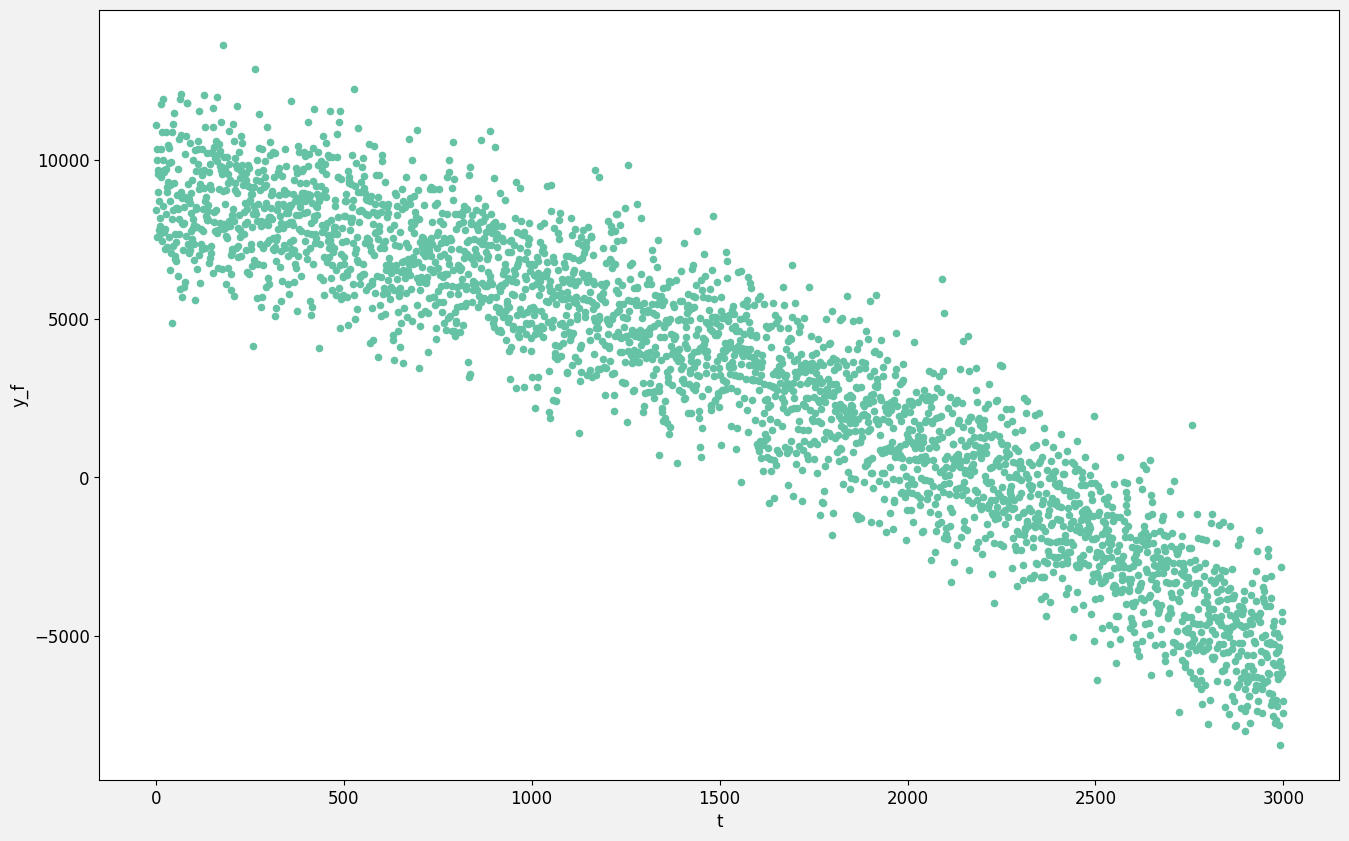

In [55]:
fakeDF.plot.scatter('t', 'y_f')
plt.show()

In [56]:
mod_f1 = smf.ols('y_f ~ t + tsq', data = fakeDF).fit()

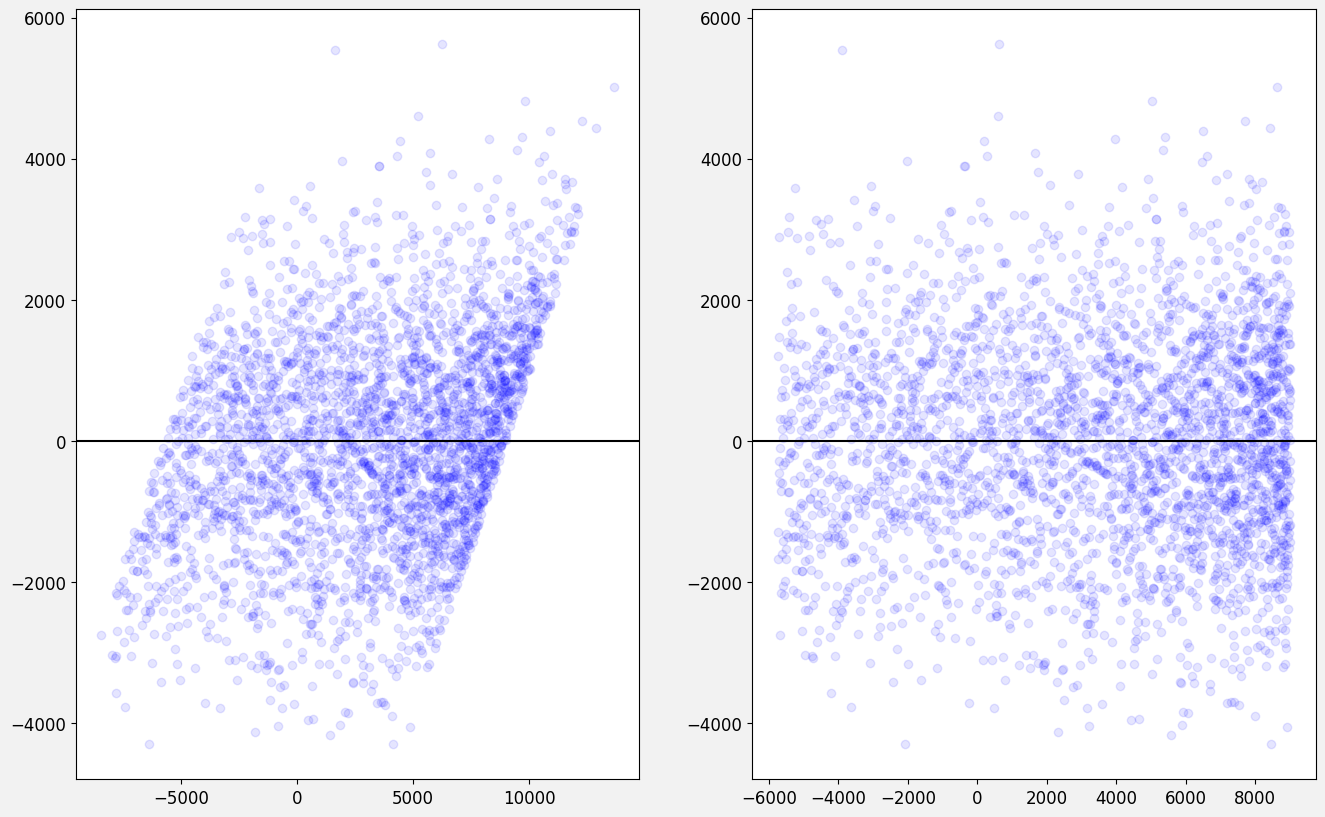

In [57]:
fig, ax = plt.subplots(1, 2)
ax[0].scatter(fakeDF['y_f'], mod_f1.resid, alpha = .1, color = 'blue')
ax[0].axhline(0, color = 'black')
ax[1].scatter(mod_f1.fittedvalues, mod_f1.resid, alpha = .1, color = 'blue')
ax[1].axhline(0, color = 'black')
plt.show()

With this made up data we know that the residuals should be completely random, yet in the panel with the residuals vs actual, there is a clear trend. This comes from the error terms (which the residuals estimate) being part of the y-values. For this reason we compare the residuals with the fitted values (which exclude the error term), as in the right panel. 

##### Posterior predictive checking

We can evaluate the models apropriateness further by doing posterior predictive checking. 

In [58]:
# Creating 20 new sets of fake data, each set is based on the simulated parameters (using the function from above.)
nsim = 20

x_line = np.linspace(0, T, T)
x_line_m = x_line - np.mean(x_line)

y_fs = []

for i in range(nsim):
    bs_sim, sigma_sim = regSim(mod1)
    y_fs.append(bs_sim[0] + bs_sim[1] * x_line_m + mod1.params.iloc[2] * x_line_m ** 2 + np.random.normal(0, sigma_sim, T))

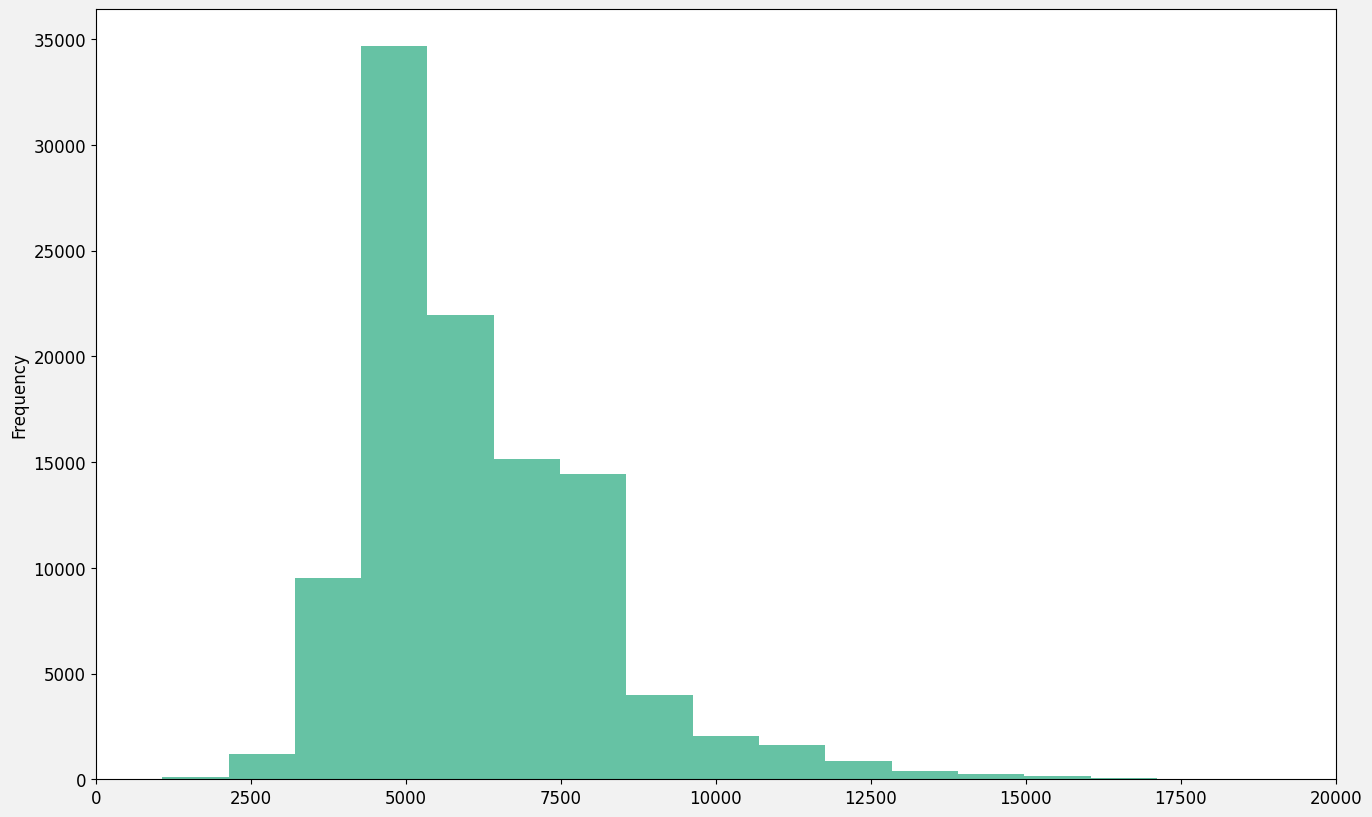

In [62]:
# Creating a histgram of the actual data:
fig, ax = plt.subplots()
pv['cost_per_kw'].plot.hist(bins = 100, ax = ax)
ax.set_xlim(0, 20000)
plt.show()

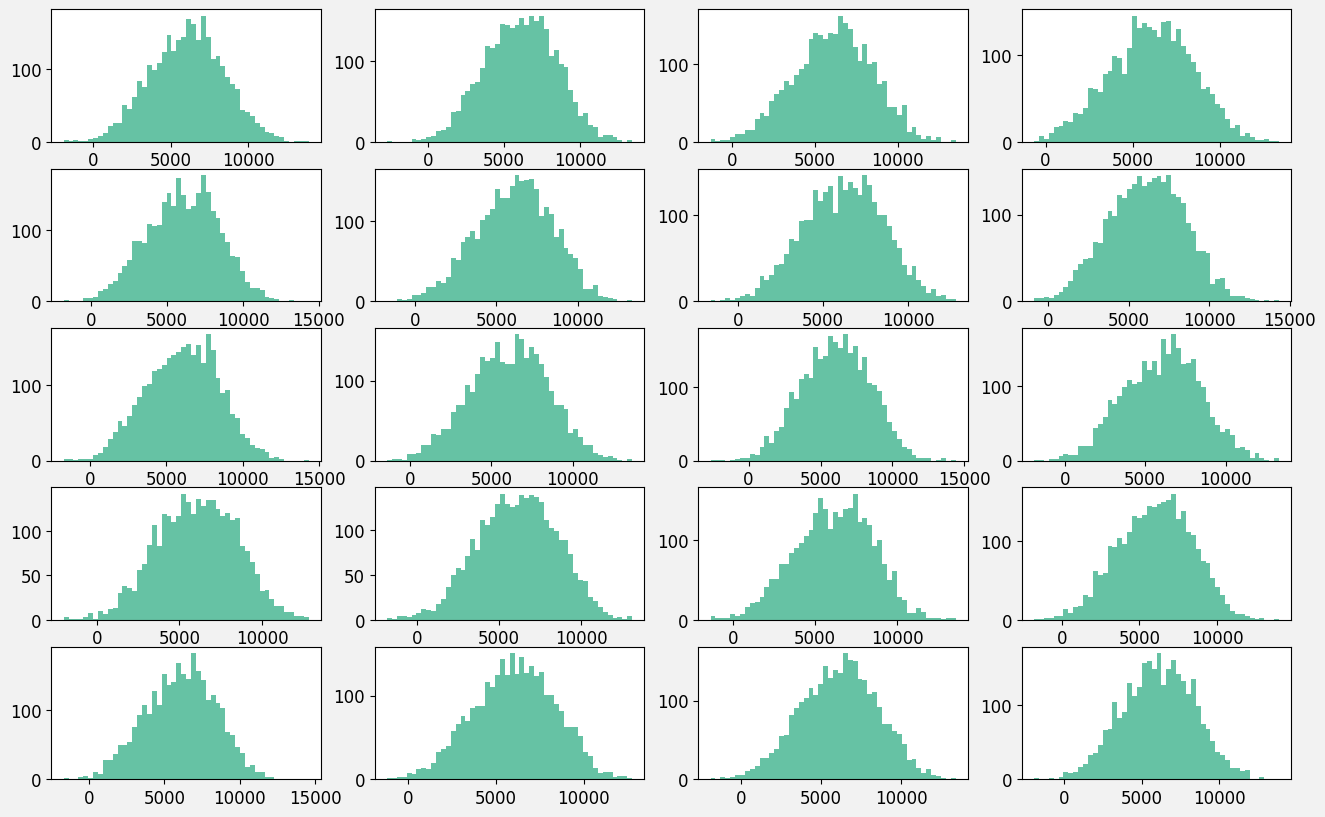

In [63]:
# Now for displaying the 20 fake data sets:
fig, ax = plt.subplots(5, 4)
i = 0
for row in range(5):
    for col in range(4):
        ax[row, col].hist(y_fs[i], bins = 50)
        i += 1
plt.show()

In [66]:
yf_df = pd.DataFrame(np.transpose(y_fs))
colnames = ['sim' + str(i + 1) for i in range(20)]
yf_df.columns = colnames
yf_df.head()

,sim1,sim2,sim3,sim4,sim5,sim6,sim7,sim8,sim9,sim10,sim11,sim12,sim13,sim14,sim15,sim16,sim17,sim18,sim19,sim20
0,7659.517092,7685.670136,5283.561485,9446.036656,9302.371719,8898.545460,8408.645915,9913.228170,9505.941523,8101.769478,9509.081425,7652.735313,10257.465100,7194.106422,9734.255789,5972.333681,7486.180326,7686.627235,7424.681942,7636.539380
1,11249.681643,6773.725499,6403.985759,9048.955029,8293.533505,8973.886646,8464.229677,11060.527936,6504.135644,8916.093964,7260.382915,9359.322345,7939.943468,10738.561296,10742.441667,6065.980219,8166.701441,5965.262828,7469.031203,7512.218309
2,7082.802926,7514.165962,8321.815663,8691.792585,12730.558565,9792.845722,7611.087223,8879.278389,9620.543537,7705.814566,6946.559601,6805.974560,7954.974370,9840.243909,10396.253200,8641.872172,8609.803775,8218.821061,9573.724935,5234.659416
3,7602.316820,9177.264640,6345.466084,12431.321092,7952.927121,8503.753576,9144.942641,6281.385616,7598.259826,9439.979287,7724.278499,7786.264935,5740.925948,10666.987888,6621.760118,10446.206661,2611.012808,8904.272607,8722.060298,7279.704935
4,6414.390403,8664.367940,8735.435603,7373.577045,7876.996003,7937.678505,8232.363336,7329.066817,10170.964607,8226.813605,8729.327172,5757.903553,8488.065142,7604.038396,8767.492042,7627.964840,8931.042713,8861.176233,7881.266445,11902.333799


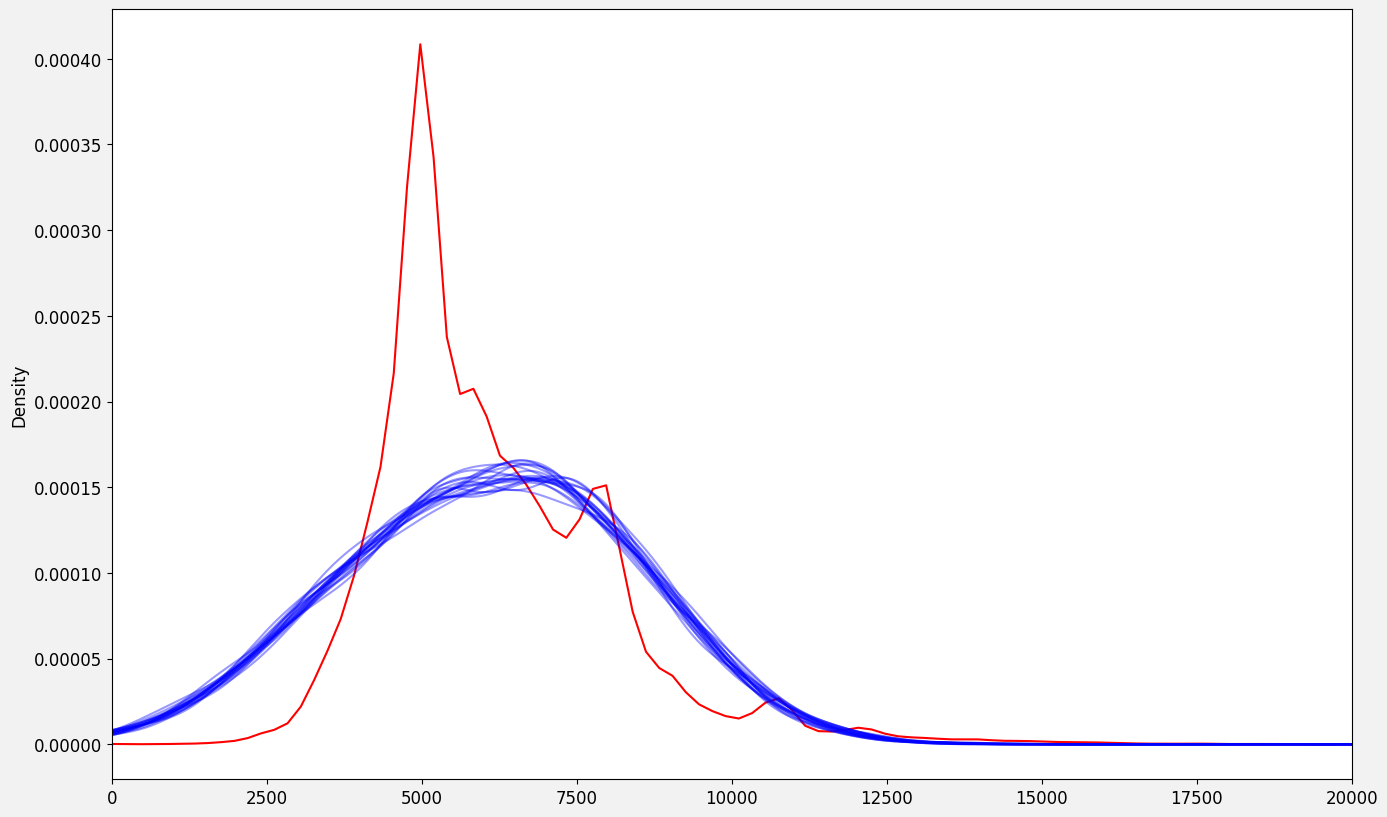

In [76]:
# Using the empirical density function (a smoothed, de-scaled histogram) from seaborn, we can plot the actual data and the simulationsusing our model on the same chart:
fig, ax = plt.subplots()
pv['cost_per_kw'].plot.density(ax = ax, color = 'red')

for name, values in yf_df.items():
    values.plot.density(ax = ax, alpha = .4, color = 'blue')

ax.set_xlim(0, 20000)
plt.show()

Clearly the actual data and the simulated data from the estimated model are quite different. This suggests that a quadratic time trend alone is not a good representation of the data.

##### Overfitting and AIC (Akaiki Information Criteria)

With a large data set including several potential explanatory variables in a model, you risk overfitting the model, this means that you could create a model with a good fit in terms of traditional measures such as r-squared, but which would perform poorly on out-of-sample data, which is what we generally want (whether it is inference or prediction we are interested in). <br><br> There are many tools for avoiding overfitting, one of the most common is information criteria: AIC, or the similar BIC (Bayesian Information Criteria). These criteria basically penalize the number of variables used in the regression relative to the fit of the model. When comparing models with AIC (or BIC) you want the model with the lowest value. <br><br> To examplify this I will make three regression models (estimated by maximum likelihood, using the smf.glm routine) with the PV data. The first model will have several explanatory variables:

In [78]:
ICmod1 = smf.glm('cost_per_kw ~ time_days + time_days_sq + nameplate + sector + incentive_amount + contractor_year_total + county_year_total + nationality + county', data = pv).fit()
ICmod1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            cost_per_kw   No. Observations:               104992
Model:                            GLM   Df Residuals:                   104921
Model Family:                Gaussian   Df Model:                           70
Link Function:               Identity   Scale:                      2.5645e+06
Method:                          IRLS   Log-Likelihood:            -9.2364e+05
Date:                Tue, 05 Dec 2023   Deviance:                   2.6907e+11
Time:                        16:28:28   Pearson chi2:                 2.69e+11
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4667
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   8175.3223     60.653    134.788      0.000    8056.444    8294.200
sector[T.Government]        1553.8691     95.277     16.309      0.000    1367.130    1740.608
sector[T.Non-Profit]        -394.0940     93.473     -4.216      0.000    -577.298    -210.890
sector[T.Residential]        141.0004     42.322      3.332      0.001      58.050     223.950
nationality[T.China]          -9.5275     23.205     -0.411      0.681     -55.009      35.954
nationality[T.Germany]       237.5124     25.727      9.232      0.000     187.088     287.937
nationality[T.India]        -416.9158    116.606     -3.575      0.000    -645.459    -188.372
nationality[T.Japan]         743.7618     23.208     32.048      0.000     698.276     789.248
nationality[T.Norway]        299.5515     28.062     10.675      0.000     244.552     354.551
nationality[T.South Korea]  -313.9075     31.349    -10.013      0.000    -375.351    -252.464
nationality[T.Spain]         541.6003     31.456     17.218      0.000     479.948     603.253
nationality[T.Taiwan]         -4.4749     58.220     -0.077      0.939    -118.584     109.634
nationality[T.US]            240.9810     24.312      9.912      0.000     193.330     288.632
county[T.Amador]            -610.8413    141.328     -4.322      0.000    -887.840    -333.843
county[T.Butte]             -796.2775     67.392    -11.816      0.000    -928.363    -664.192
county[T.Calaveras]         -698.5247    100.898     -6.923      0.000    -896.281    -500.769
county[T.Colusa]            -687.6262    203.560     -3.378      0.001   -1086.597    -288.656
county[T.Contra Costa]        31.9526     36.682      0.871      0.384     -39.943     103.848
county[T.El Dorado]         -432.0518     54.580     -7.916      0.000    -539.026    -325.078
county[T.Fresno]            -408.3648     36.137    -11.301      0.000    -479.191    -337.538
county[T.Glenn]             -653.4635    135.800     -4.812      0.000    -919.627    -387.300
county[T.Humboldt]          -157.7739    143.659     -1.098      0.272    -439.341     123.793
county[T.Imperial]         -1574.0199    716.694     -2.196      0.028   -2978.714    -169.326
county[T.Inyo]              -696.7596    258.177     -2.699      0.007   -1202.777    -190.743
county[T.Kern]              -233.0457     37.348     -6.240      0.000    -306.246    -159.845
county[T.Kings]             -464.1639     71.612     -6.482      0.000    -604.522    -323.806
county[T.Lake]              -424.9604    117.638     -3.612      0.000    -655.528    -194.393
county[T.Lassen]           -1298.6269    534.481     -2.430      0.015   -2346.191    -251.063
county[T.Los Angeles]        453.7279     34.884     13.007      0.000     385.357     522.099
county[T.Madera]            -515.8510     7

In [80]:
# contractor_year_total is estimated to be insignificant, so the next model will be without this variable:
ICmod2 = smf.glm('cost_per_kw ~ time_days + time_days_sq + nameplate + sector + incentive_amount + county_year_total + nationality + county', data = pv).fit()
ICmod2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            cost_per_kw   No. Observations:               104992
Model:                            GLM   Df Residuals:                   104922
Model Family:                Gaussian   Df Model:                           69
Link Function:               Identity   Scale:                      2.5645e+06
Method:                          IRLS   Log-Likelihood:            -9.2364e+05
Date:                Tue, 05 Dec 2023   Deviance:                   2.6907e+11
Time:                        16:31:00   Pearson chi2:                 2.69e+11
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4667
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   8168.6765     60.478    135.068      0.000    8050.142    8287.211
sector[T.Government]        1556.9459     95.253     16.345      0.000    1370.253    1743.639
sector[T.Non-Profit]        -393.8143     93.474     -4.213      0.000    -577.019    -210.609
sector[T.Residential]        144.1989     42.264      3.412      0.001      61.362     227.035
nationality[T.China]           1.1283     21.997      0.051      0.959     -41.985      44.241
nationality[T.Germany]       236.6077     25.720      9.199      0.000     186.198     287.017
nationality[T.India]        -418.4223    116.602     -3.588      0.000    -646.958    -189.887
nationality[T.Japan]         746.8675     23.107     32.321      0.000     701.578     792.157
nationality[T.Norway]        302.2982     27.997     10.798      0.000     247.425     357.171
nationality[T.South Korea]  -308.2476     31.103     -9.911      0.000    -369.208    -247.287
nationality[T.Spain]         543.0528     31.440     17.273      0.000     481.432     604.674
nationality[T.Taiwan]          3.0341     57.987      0.052      0.958    -110.618     116.686
nationality[T.US]            243.3217     24.258     10.030      0.000     195.776     290.867
county[T.Amador]            -612.3528    141.325     -4.333      0.000    -889.345    -335.361
county[T.Butte]             -797.4236     67.387    -11.833      0.000    -929.500    -665.347
county[T.Calaveras]         -701.1570    100.882     -6.950      0.000    -898.881    -503.433
county[T.Colusa]            -689.9858    203.555     -3.390      0.001   -1088.946    -291.026
county[T.Contra Costa]        31.1818     36.678      0.850      0.395     -40.707     103.070
county[T.El Dorado]         -431.6335     54.579     -7.908      0.000    -538.607    -324.660
county[T.Fresno]            -407.7568     36.134    -11.284      0.000    -478.579    -336.935
county[T.Glenn]             -655.6697    135.792     -4.828      0.000    -921.817    -389.522
county[T.Humboldt]          -161.0505    143.642     -1.121      0.262    -442.584     120.483
county[T.Imperial]         -1577.7406    716.693     -2.201      0.028   -2982.433    -173.049
county[T.Inyo]              -702.7806    258.144     -2.722      0.006   -1208.734    -196.827
county[T.Kern]              -231.7396     37.337     -6.207      0.000    -304.919    -158.561
county[T.Kings]             -462.7958     71.606     -6.463      0.000    -603.142    -322.450
county[T.Lake]              -426.7657    117.632     -3.628      0.000    -657.321    -196.210
county[T.Lassen]           -1305.1601    534.465     -2.442      0.015   -2352.692    -257.628
county[T.Los Angeles]        453.9785     34.883     13.014      0.000     385.608     522.349
county[T.Madera]            -515.8495     7

In [81]:
# The county indicator increases the number of variables significantly and some are also insignificant, so the next model excludes this variable (and like the model above I keep contractor_year_total out):
ICmod3 = smf.glm('cost_per_kw ~ time_days + time_days_sq + nameplate + sector + incentive_amount + nationality', data = pv).fit()
ICmod3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:            cost_per_kw   No. Observations:               104992
Model:                            GLM   Df Residuals:                   104975
Model Family:                Gaussian   Df Model:                           16
Link Function:               Identity   Scale:                      2.6810e+06
Method:                          IRLS   Log-Likelihood:            -9.2600e+05
Date:                Tue, 05 Dec 2023   Deviance:                   2.8144e+11
Time:                        16:34:35   Pearson chi2:                 2.81e+11
No. Iterations:                     3   Pseudo R-squ. (CS):             0.4273
Covariance Type:            nonrobust                                         
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                   7985.5386     56.364    141.677      0.000    7875.066    8096.011
sector[T.Government]        1493.4022     97.157     15.371      0.000    1302.979    1683.826
sector[T.Non-Profit]        -309.7680     95.410     -3.247      0.001    -496.768    -122.768
sector[T.Residential]        188.6990     43.035      4.385      0.000     104.353     273.045
nationality[T.China]         -46.4572     22.424     -2.072      0.038     -90.407      -2.507
nationality[T.Germany]       171.9836     26.155      6.576      0.000     120.721     223.247
nationality[T.India]        -387.5888    119.138     -3.253      0.001    -621.096    -154.082
nationality[T.Japan]         721.5237     23.553     30.635      0.000     675.361     767.686
nationality[T.Norway]        238.2810     28.398      8.391      0.000     182.622     293.940
nationality[T.South Korea]  -328.4855     31.729    -10.353      0.000    -390.673    -266.298
nationality[T.Spain]         541.0854     32.054     16.880      0.000     478.260     603.910
nationality[T.Taiwan]        -28.6208     59.220     -0.483      0.629    -144.690      87.449
nationality[T.US]            228.5375     24.761      9.230      0.000     180.008     277.067
time_days                     -0.6895      0.038    -18.117      0.000      -0.764      -0.615
time_days_sq                  -0.0003   1.14e-05    -22.501      0.000      -0.000      -0.000
nameplate                    -10.0513      0.617    -16.300      0.000     -11.260      -8.843
incentive_amount               0.0042      0.000     18.023      0.000       0.004       0.005
==============================================================================================
"""

In [82]:
# Time for the AIC values:
print('AIC for model 1: ', ICmod1.aic)
print('AIC for model 2: ', ICmod2.aic)
print('AIC for model 3: ', ICmod3.aic)

AIC for model 1:  1847420.669942441
AIC for model 2:  1847420.7497015435
AIC for model 3:  1852032.7639825707


The actual numbers do not tell us anything, but the relative sizes is relevant. From the AIC values we can see that model 1 is the best regardless of removing insignificant and sizable variables. 

In [85]:
# Time for the BIC values:
print('BIC for model 1: ', ICmod1.bic)
print('BIC for model 2: ', ICmod2.bic)
print('BIC for model 3: ', ICmod3.bic)

BIC for model 1:  269067625809.17706
BIC for model 2:  269072955764.74927
BIC for model 3:  281440101852.5955


C:\Users\sebal\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\genmod\generalized_linear_model.py:1838: FutureWarning: The bic value is computed using the deviance formula. After 0.13 this will change to the log-likelihood based formula. This change has no impact on the relative rank of models compared using BIC. You can directly access the log-likelihood version using the `bic_llf` attribute. You can suppress this message by calling statsmodels.genmod.generalized_linear_model.SET_USE_BIC_LLF with True to get the LLF-based version now or False to retainthe deviance version.
  warnings.warn(


We get the same results from both AIC and BIC. BIC, however, tends to 'prefer' fewer explanatory variables. If AIC and BIC gives conflicting indications, the choice will come down to whether a variable has a good reason to be included in the model from a theoretical perspective.

Cross validation can also be a good tool for avoiding overfitting.